# Assignment 1

Bài toán phân loại (classification) trên ba loại dữ liệu: ảnh, văn bản và đa phương thức (ảnh + văn bản).

Import thư viện

In [29]:
# ── Standard Library ──────────────────────────────────────────────────────────
import os
import re
import time
import random
import warnings
warnings.filterwarnings('ignore')

# ── Data Manipulation ─────────────────────────────────────────────────────────
import numpy as np
import pandas as pd

# ── Visualization ─────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from collections import Counter

# ── PyTorch ───────────────────────────────────────────────────────────────────
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW

# ── Sklearn Metrics ───────────────────────────────────────────────────────────
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, f1_score,
    classification_report, confusion_matrix
)

# ── Reproducibility ───────────────────────────────────────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

# ── Device Configuration ──────────────────────────────────────────────────────
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'   Using device: {device}')
if device.type == 'cuda':
    print(f'   GPU: {torch.cuda.get_device_name(0)}')
    print(f'   Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')

   Using device: cpu


# 2. Dataset Loading & Exploratory Data Analysis

In [6]:
from datasets import load_dataset
import pandas as pd

print("Đang tải dữ liệu... Vui lòng chờ giây lát.")
dataset = load_dataset("imdb")
print(type(dataset['train']))
df = pd.concat([pd.DataFrame(dataset['train']), pd.DataFrame(dataset['test'])])

# 4. Lưu dữ liệu ra file CSV (nếu bạn muốn dùng sau này)
# train_df.to_csv("imdb_train.csv", index=False)
# print("\nĐã lưu tập train vào file 'imdb_train.csv'")


Đang tải dữ liệu... Vui lòng chờ giây lát.
<class 'datasets.arrow_dataset.Dataset'>


# EDA

In [7]:
print(f'Dataset shape : {df.shape}')
print(f'Columns       : {list(df.columns)}')
# print(f'Null values   :\n{df.isnull().sum()}')
print(df.describe())
print(df.info())
print(df['label'].value_counts())
df.head()

Dataset shape : (50000, 2)
Columns       : ['text', 'label']
              label
count  50000.000000
mean       0.500000
std        0.500005
min        0.000000
25%        0.000000
50%        0.500000
75%        1.000000
max        1.000000
<class 'pandas.core.frame.DataFrame'>
Index: 50000 entries, 0 to 24999
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   text    50000 non-null  object
 1   label   50000 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 1.1+ MB
None
label
0    25000
1    25000
Name: count, dtype: int64


,text,label
0,I rented I AM CURIOUS-YELLOW from my video sto...,0
1,"""I Am Curious: Yellow"" is a risible and preten...",0
2,If only to avoid making this type of film in t...,0
3,This film was probably inspired by Godard's Ma...,0
4,"Oh, brother...after hearing about this ridicul...",0


Note:

- Label 0: Negative (Tiêu cực/Chê). Bài đánh giá có nội dung không hài lòng về bộ phim.
- Label 1: Positive (Tích cực/Khen). Bài đánh giá có nội dung yêu thích hoặc đánh giá cao bộ phim.

##  Class distribution

label
0    25000
1    25000
Name: count, dtype: int64


([<matplotlib.patches.Wedge at 0x7c1c2f0682c0>,
 [Text(-0.7392056177253551, -0.8809512215345844, 'Positive'),
  Text(0.7070663702780942, 0.8426488877472997, 'Negative')],
 [Text(-0.4178118708882441, -0.49792895130215636, '50.0%'),
  Text(0.38567256560623314, 0.4596266660439816, '50.0%')])

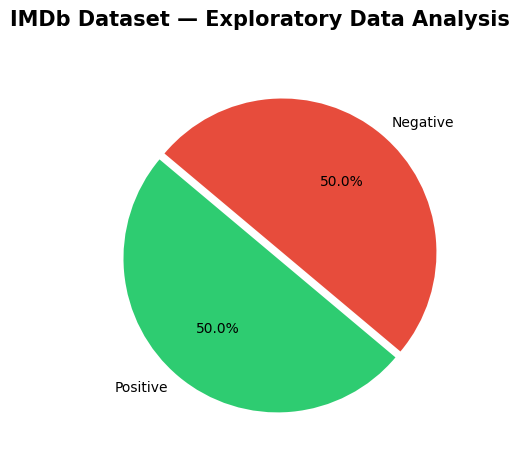

In [10]:
label_counts = df['label'].value_counts()
print(label_counts)

fig, axis = plt.subplots(1, 1, figsize=(18, 5))
fig.suptitle('IMDb Dataset — Exploratory Data Analysis', fontsize=15, fontweight='bold')
colors = ['#2ecc71', '#e74c3c']
# axis[0].bar(label_counts.index, label_counts.values, color=colors, width=0.5, edgecolor='white', linewidth=1.5)
axis.pie(label_counts, 
            labels=['Positive', 'Negative'], 
            autopct='%1.1f%%', 
            startangle=140, 
            colors=colors, 
            explode=(0.05, 0))

## Length

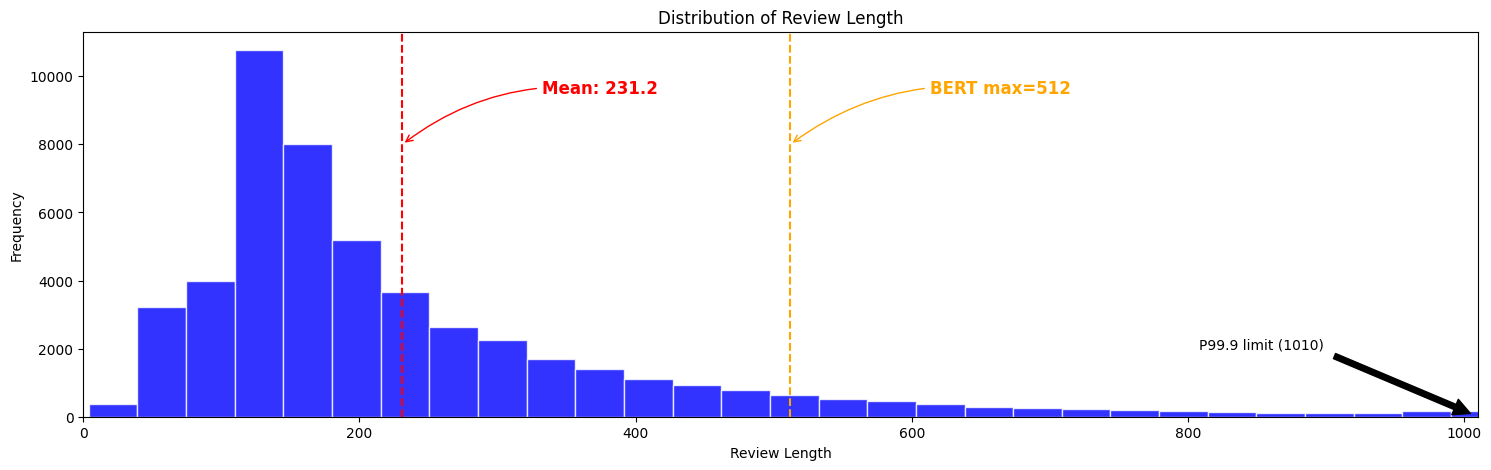

In [11]:
import seaborn as sns

df['review_length'] = df['text'].apply(lambda x: len(x.split()))
df.head()
fig, axes = plt.subplots(1, 1, figsize=(18, 5))
mean_val = df['review_length'].mean()
p999 = df['review_length'].quantile(0.999)

axes.hist(df['review_length'], bins=70, color='blue', alpha=0.8, edgecolor='white')
axes.axvline(df['review_length'].mean(), color='red', linestyle='--', label=f'Mean={mean_val:.0f}')
axes.annotate(
    f'Mean: {mean_val:.1f}', 
    xy=(mean_val, 8000),           
    xytext=(mean_val + p999*0.1, 9500), 
    fontsize=12, 
    fontweight='bold', 
    color='red',
    arrowprops=dict(
        arrowstyle="->",          
        connectionstyle="arc3,rad=.2",
        color='red'
    )
)
axes.axvline(512, color='orange', linestyle='--', label='BERT max=512')
axes.annotate(
    f'BERT max=512', 
    xy=(512, 8000),           
    xytext=(512 + p999*0.1, 9500), 
    fontsize=12, 
    fontweight='bold', 
    color='orange',
    arrowprops=dict(
        arrowstyle="->",          
        connectionstyle="arc3,rad=.2",
        color='orange'
    )
)
axes.set_title('Distribution of Review Length')
axes.set_xlabel('Review Length')
axes.set_ylabel('Frequency')

axes.set_xlim(0, p999)
axes.annotate(f'P99.9 limit ({p999:.0f})', 
                 xy=(p999, 0), xytext=(p999*0.8, 2000),
                 arrowprops=dict(facecolor='black', shrink=0.05))

fig.show()

# Plot 3: Reviews > 512 tokens

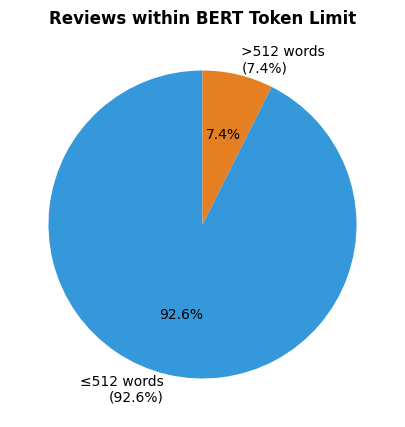


 Review length stats:
count    50000.0
mean       231.2
std        171.3
min          4.0
25%        126.0
50%        173.0
75%        280.0
max       2470.0
Name: review_length, dtype: float64


In [12]:
over_512 = (df['review_length'] > 512).sum()
fig, axes = plt.subplots(1, 1, figsize=(18, 5))
within_512 = len(df) - over_512
axes.pie([within_512, over_512],
            labels=[f'≤512 words\n({within_512/len(df)*100:.1f}%)', f'>512 words\n({over_512/len(df)*100:.1f}%)'],
            colors=['#3498db', '#e67e22'], autopct='%1.1f%%', startangle=90)
axes.set_title('Reviews within BERT Token Limit', fontweight='bold')

# plt.tight_layout()
# plt.savefig('eda_plots.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'\n Review length stats:')
print(df['review_length'].describe().round(1))


## wordcloud

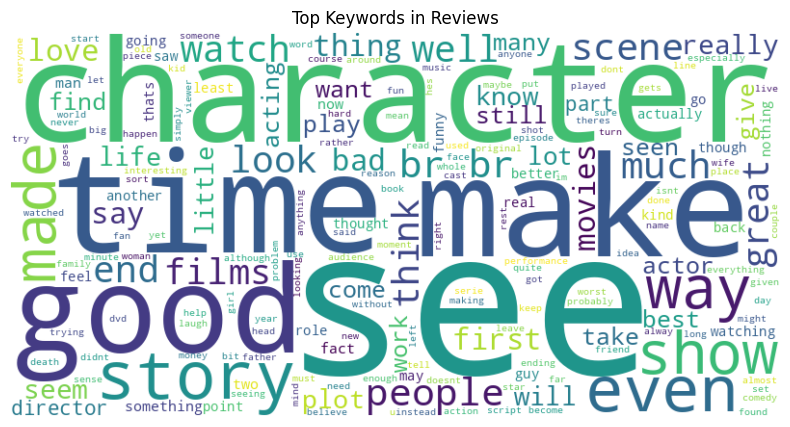

In [13]:
import matplotlib.pyplot as plt
from wordcloud import WordCloud, STOPWORDS
import re

# 1. Thu thập và tiền xử lý văn bản
# Lấy tất cả văn bản từ cột 'review' và nối lại thành một chuỗi lớn
all_text = ' '.join(df['text'].str.lower()) # Chuyển về chữ thường để tránh phân biệt HOA/thường

# Loại bỏ các ký tự đặc biệt, dấu câu, v.v. để sạch dữ liệu
cleaned_text = re.sub(r'[^a-zA-Z0-9\s]', '', all_text)

# 2. Tạo đối tượng WordCloud
# Sử dụng STOPWORDS mặc định của thư viện để loại bỏ các từ vô nghĩa (the, is, at, v.v.)
# Bạn cũng có thể thêm stopwords tùy chỉnh của riêng mình vào đây
stopwords = set(STOPWORDS)
stopwords.update(["movie", "film", "one", "like"]) # Thêm các từ phổ biến không mang nhiều ý nghĩa

wc = WordCloud(
    background_color='white',    # Màu nền
    max_words=200,                # Số lượng từ tối đa hiển thị
    stopwords=stopwords,        # Danh sách các từ cần loại bỏ
    width=800,                    # Chiều rộng
    height=400                    # Chiều cao
)

# Tạo WordCloud từ văn bản
wc.generate(cleaned_text)
fig, axes = plt.subplots(1, 1, figsize=(18, 5))
# 3. Vẽ WordCloud vào ô thứ 3 (axis[2])
axes.imshow(wc, interpolation='bilinear') # Hiển thị hình ảnh
axes.axis('off')                             # Tắt trục tọa độ (axis) để nhìn đẹp hơn
axes.set_title('Top Keywords in Reviews', fontsize=12) # Đặt tiêu đề cho biểu đồ

# 4. Hiển thị toàn bộ Dashboard
#plt.tight_layout() # Tự động căn chỉnh các biểu đồ không đè lên nhau (nếu cần)
plt.show()

# 3. Data Preprocessing & Tokenization

In [14]:
def clean_text(text: str) -> str:
    """Remove HTML tags and normalize whitespace."""
    text = text.lower() 
    text = re.sub(r'<[^>]+>', '', text)          # strip HTML tags
    text = re.sub(r'[^a-zA-Z\s!?.,\'"\-]', '', text)  # keep letters & basic punctuation
    text = re.sub(r'\s+', ' ', text).strip()     # normalize whitespace
    return text

df['clean_review'] = df['text'].apply(clean_text).fillna('')
df['clean_review'].head()

,clean_review
0,i rented i am curious-yellow from my video sto...
1,"""i am curious yellow"" is a risible and pretent..."
2,if only to avoid making this type of film in t...
3,this film was probably inspired by godard's ma...
4,"oh, brother...after hearing about this ridicul..."


In [15]:
print('Sample cleaned review:')
print('-' * 60)
print('Original :', df['text'].iloc[0][:512])
print('Cleaned  :', df['clean_review'].iloc[0][:512])
print('-' * 60)
print(f'Label mapping: positive=1, negative=0')

Sample cleaned review:
------------------------------------------------------------
Original : I rented I AM CURIOUS-YELLOW from my video store because of all the controversy that surrounded it when it was first released in 1967. I also heard that at first it was seized by U.S. customs if it ever tried to enter this country, therefore being a fan of films considered "controversial" I really had to see this for myself.<br /><br />The plot is centered around a young Swedish drama student named Lena who wants to learn everything she can about life. In particular she wants to focus her attentions to maki
Cleaned  : i rented i am curious-yellow from my video store because of all the controversy that surrounded it when it was first released in . i also heard that at first it was seized by u.s. customs if it ever tried to enter this country, therefore being a fan of films considered "controversial" i really had to see this for myself.the plot is centered around a young swedish drama student n

### Tokenizer for bert

In [ ]:
from transformers import (
    BertTokenizer,
    BertForSequenceClassification,
    get_linear_schedule_with_warmup
)

MODEL_NAME = "bert-base-uncased"
MAX_LEN = 512

tokenizer = BertTokenizer.from_pretrained(MODEL_NAME)


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

{'input_ids': tensor([[  101,  1045, 12524,  1045,  2572,  8025,  1011,  3756,  2013,  2026,
          2678,  3573,  2138,  1997,  2035,  1996,  6704,  2008,  5129,  2009,
          2043,  2009,  2001,  2034,  2207,  1999,  1012,  1045,  2036,  2657,
          2008,  2012,  2034,  2009,  2001,  8243,  2011,  1057,  1012,  1055,
          1012,  8205,  2065,  2009,  2412,  2699,  2000,  4607,  2023,  2406,
          1010,  3568,  2108,  1037,  5470,  1997,  3152,  2641,  1000,  6801,
          1000,  1045,  2428,  2018,  2000,  2156,  2023,  2005,  2870,  1012,
          1996,  5436,  2003,  8857,  2105,  1037,  2402,  4467,  3689,  3076,
          2315, 14229,  2040,  4122,  2000,  4553,  2673,  2016,  2064,  2055,
          2166,  1012,  1999,  3327,  2016,  4122,  2000,  3579,  2014,  3086,
          2015,  2000,  2437,  2070,  4066,  1997,   102]]), 'token_type_ids': tensor([[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0, 0, 0, 0, 0, 0, 0, 

In [40]:
sample = 'i rented i am curious-yellow from my video store because of all the controversy that surrounded it when it was first released in . i also heard that at first it was seized by u.s. customs if it ever tried to enter this country, therefore being a fan of films considered "controversial" i really had to see this for myself.the plot is centered around a young swedish drama student named lena who wants to learn everything she can about life. in particular she wants to focus her attentions to making some sort of'
encoded = tokenizer(sample, max_length=MAX_LEN, padding="max_length", truncation=True, return_tensors='pt')
print(encoded)


{'input_ids': tensor([[  101,  1045, 12524,  1045,  2572,  8025,  1011,  3756,  2013,  2026,
          2678,  3573,  2138,  1997,  2035,  1996,  6704,  2008,  5129,  2009,
          2043,  2009,  2001,  2034,  2207,  1999,  1012,  1045,  2036,  2657,
          2008,  2012,  2034,  2009,  2001,  8243,  2011,  1057,  1012,  1055,
          1012,  8205,  2065,  2009,  2412,  2699,  2000,  4607,  2023,  2406,
          1010,  3568,  2108,  1037,  5470,  1997,  3152,  2641,  1000,  6801,
          1000,  1045,  2428,  2018,  2000,  2156,  2023,  2005,  2870,  1012,
          1996,  5436,  2003,  8857,  2105,  1037,  2402,  4467,  3689,  3076,
          2315, 14229,  2040,  4122,  2000,  4553,  2673,  2016,  2064,  2055,
          2166,  1012,  1999,  3327,  2016,  4122,  2000,  3579,  2014,  3086,
          2015,  2000,  2437,  2070,  4066,  1997,   102,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,  

In [41]:
tokens = tokenizer.convert_ids_to_tokens(encoded['input_ids'][0])
non_pad = [t for t in tokens if t != '[PAD]']

print(f' Tokenizer loaded: {MODEL_NAME}')
print(f'   Vocab size       : {tokenizer.vocab_size:,}')
print(f'   Max sequence len : {MAX_LEN}')
print(f'\nSample tokenization:')
print(f'   Input    : "{sample}"')
print(f'   Tokens   : {non_pad}')
print(f'   Input IDs shape  : {encoded["input_ids"].shape}')
print(f'   Attention mask   : {encoded["attention_mask"][0][:len(non_pad)].tolist()}')

 Tokenizer loaded: bert-base-uncased
   Vocab size       : 30,522
   Max sequence len : 512

Sample tokenization:
   Input    : "i rented i am curious-yellow from my video store because of all the controversy that surrounded it when it was first released in . i also heard that at first it was seized by u.s. customs if it ever tried to enter this country, therefore being a fan of films considered "controversial" i really had to see this for myself.the plot is centered around a young swedish drama student named lena who wants to learn everything she can about life. in particular she wants to focus her attentions to making some sort of"
   Tokens   : ['[CLS]', 'i', 'rented', 'i', 'am', 'curious', '-', 'yellow', 'from', 'my', 'video', 'store', 'because', 'of', 'all', 'the', 'controversy', 'that', 'surrounded', 'it', 'when', 'it', 'was', 'first', 'released', 'in', '.', 'i', 'also', 'heard', 'that', 'at', 'first', 'it', 'was', 'seized', 'by', 'u', '.', 's', '.', 'customs', 'if', 'it', 'ever'

# 4. PyTorch Dataset & DataLoaders

In [48]:
class IMDbDataset(Dataset):
    def __init__(self, reviews: pd.Series, labels: pd.Series, tokenizer: BertTokenizer, max_len: int = 512):
        self.reviews = reviews.reset_index(drop=True)
        self.labels = labels.reset_index(drop=True)
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self) -> int:
        return len(self.reviews)

    def __getitem__(self, idx: int) -> dict:
        review = str(self.reviews[idx])
        label = int(self.labels[idx])

        encoding = self.tokenizer.encode_plus(
            review,
            add_special_tokens=True,
            max_length=self.max_len,
            padding='max_length',
            truncation=True,
            return_attention_mask=True,
            return_tensors='pt',
        )
        
        return {
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'label': torch.tensor(label, dtype=torch.long)
        }

In [46]:
df_sample = df.sample(n=1_000, random_state=SEED).reset_index(drop=True)
df_sample.head()

X_train, X_temp, y_train, y_temp = train_test_split(df_sample['clean_review'], df_sample['label'], test_size=0.2, random_state=SEED, stratify=df_sample['label'])
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.50, random_state=SEED, stratify=y_temp)
print(f'Split sizes → Train: {len(X_train):,} | Val: {len(X_val):,} | Test: {len(X_test):,}')


Split sizes → Train: 800 | Val: 100 | Test: 100


In [49]:
BATCH_SIZE = 16
train_dataset = IMDbDataset(X_train, y_train, tokenizer, MAX_LEN)
val_dataset   = IMDbDataset(X_val,   y_val,   tokenizer, MAX_LEN)
test_dataset  = IMDbDataset(X_test,  y_test,  tokenizer, MAX_LEN)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

# Verify a batch
batch = next(iter(train_loader))
print(f'\nBatch shapes:')
print(f'  input_ids      : {batch["input_ids"].shape}')
print(f'  attention_mask : {batch["attention_mask"].shape}')
print(f'  labels         : {batch["label"].shape}')



Batch shapes:
  input_ids      : torch.Size([16, 512])
  attention_mask : torch.Size([16, 512])
  labels         : torch.Size([16])


# 5. Model Architecture

In [50]:
# ── Load Pre-trained BERT ─────────────────────────────────────────────────────
model = BertForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=2,
    output_attentions=False,
    output_hidden_states=False
)
model = model.to(device)

# Model summary
total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f' Model loaded: {MODEL_NAME}')
print(f'   Total parameters    : {total_params:,}')
print(f'   Trainable parameters: {trainable_params:,}')
print(f'   Architecture        : {model.config.architectures}')
print(f'   Hidden size         : {model.config.hidden_size}')
print(f'   Num attention heads : {model.config.num_attention_heads}')
print(f'   Num hidden layers   : {model.config.num_hidden_layers}')

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


 Model loaded: bert-base-uncased
   Total parameters    : 109,483,778
   Trainable parameters: 109,483,778
   Architecture        : ['BertForMaskedLM']
   Hidden size         : 768
   Num attention heads : 12
   Num hidden layers   : 12


In [ ]:
# ── Optimizer & Scheduler ─────────────────────────────────────────────────────
EPOCHS       = 3
LR           = 2e-5     # Standard BERT fine-tuning range: 2e-5 to 5e-5
WARMUP_RATIO = 0.1

total_steps  = len(train_loader) * EPOCHS
warmup_steps = int(total_steps * WARMUP_RATIO)

# AdamW with weight decay (exclude bias and LayerNorm)
no_decay = ['bias', 'LayerNorm.weight']
optimizer_grouped_parameters = [
    {'params': [p for n, p in model.named_parameters() if not any(nd in n for nd in no_decay)],
     'weight_decay': 0.01},
    {'params': [p for n, p in model.named_parameters() if any(nd in n for nd in no_decay)],
     'weight_decay': 0.0}
]

optimizer = AdamW(optimizer_grouped_parameters, lr=LR, eps=1e-8)
scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=warmup_steps,
    num_training_steps=total_steps
)

print(f'Optimizer : AdamW (lr={LR}, weight_decay=0.01)')
print(f'Scheduler : Linear warmup + decay')
print(f'Epochs    : {EPOCHS}')
print(f'Total steps  : {total_steps:,}')
print(f'Warmup steps : {warmup_steps:,}')
